## Настройка окружения

In [142]:
import os
import torch
import warnings
import matplotlib
import numpy as np
import pandas as pd
import seaborn as sns
from math import ceil 
import torch.nn as nn 
from pathlib import Path
from functools import reduce
import matplotlib.pyplot as plt
from sqlalchemy import create_engine
from catboost import CatBoostRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=DeprecationWarning)


In [143]:
RANDOM_STATE = 22082026

## Загрузка данных

In [144]:
!curl -O https://code.s3.yandex.net/data-scientist/ds-plus-final.db

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed

  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 3504k  100 3504k    0     0  14.7M      0 --:--:-- --:--:-- --:--:-- 14.9M


In [145]:
path_to_db = 'ds-plus-final.db'
engine = create_engine(f'sqlite:///{path_to_db}', echo=False) 

In [146]:
engine

Engine(sqlite:///ds-plus-final.db)

## Пользовательские функции

In [147]:
def show_all_boxplots(data_frame, xlim_min=None, xlim_max=None):
    '''
    :data_frame: исходный датафрейм с интересующими полями.
    На выход выдает сетку с несколькими ящиками с усами.
    Пропускает поле с названием id и если нет числовых значений в поле.
    '''
    
    num_cols = data_frame.select_dtypes(include="number").columns
    num_cols = [col for col in num_cols if col.lower() != "id"]
    
    n = len(num_cols)
    if n == 0:
        print("Нет числовых колонок для построения boxplot.")
        return
    
    ncols = 2
    nrows = (n + ncols - 1) // ncols
    
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(14, 1.5*nrows))
    axes = axes.flatten()
    
    for i, col in enumerate(num_cols):
        ax = axes[i]
        ax.boxplot(data_frame[col].dropna(), orientation='horizontal')
        ax.set_title(col, fontsize=10)
        ax.grid(True)

        
        if xlim_min is not None and xlim_max is not None:
            ax.set_xlim(xlim_min, xlim_max)
    
    # убираем лишние оси
    for j in range(i+1, len(axes)):
        fig.delaxes(axes[j])
    
    plt.tight_layout()
    plt.show()

In [148]:
def show_all_hists(data_frame, bins=15):
    '''
    На вход принимает переменную в которой хранится исходный датафрейм.
    На выход выдает сетку с несколькими гистограмммами.
    Пропускает поле с названием id и если нет числовых значений в поле.
    '''
    # оставляем только числовые колонки
    num_cols = data_frame.select_dtypes(include="number").columns
    num_cols = [col for col in num_cols if col.lower() != "id"]  # исключаем id
    
    n = len(num_cols)
    if n == 0:
        print("Нет числовых колонок для построения гистограмм.")
        return
    
    # определим количество строк и столбцов для сетки
    ncols = 2
    nrows = (n + ncols - 1) // ncols  # округляем вверх
    
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, 2*nrows))
    axes = axes.flatten()  # превращаем в одномерный список
    
    for i, col in enumerate(num_cols):
        ax = axes[i]
        ax.hist(data_frame[col].dropna(), bins=bins, color="purple")
        ax.set_title(col)
        ax.set_ylabel('Количество, шт.')
        ax.set_xlabel('Значения признака')        
    # уберём пустые оси, если они остались
    for j in range(i+1, len(axes)):
        fig.delaxes(axes[j])
    
    plt.tight_layout()
    plt.show()

### arc df

Данные об электродах:

In [149]:
pd.read_sql_query("PRAGMA table_info(data_arc);", con=engine)

,cid,name,type,notnull,dflt_value,pk
0,0,key,INTEGER,0,None,0
1,1,Начало нагрева дугой,TEXT,0,None,0
2,2,Конец нагрева дугой,TEXT,0,None,0
3,3,Активная мощность,double,0,None,0
4,4,Реактивная мощность,double,0,None,0


In [150]:
query = '''
SELECT *
FROM data_arc;
'''

arc = pd.read_sql_query(query, con=engine)


In [151]:
arc.columns = arc.columns.str.lower().str.replace(' ', '_')

In [152]:
arc.head(3)

,key,начало_нагрева_дугой,конец_нагрева_дугой,активная_мощность,реактивная_мощность
0,1,2019-05-03 11:02:14,2019-05-03 11:06:02,0.305130,0.211253
1,1,2019-05-03 11:07:28,2019-05-03 11:10:33,0.765658,0.477438
2,1,2019-05-03 11:11:44,2019-05-03 11:14:36,0.580313,0.430460


In [153]:
arc.duplicated().sum()

np.int64(0)

In [154]:
arc.isnull().sum()

key                     0
начало_нагрева_дугой    0
конец_нагрева_дугой     0
активная_мощность       0
реактивная_мощность     0
dtype: int64

In [155]:
arc.info()

<class 'pandas.DataFrame'>
RangeIndex: 14876 entries, 0 to 14875
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   key                   14876 non-null  int64  
 1   начало_нагрева_дугой  14876 non-null  str    
 2   конец_нагрева_дугой   14876 non-null  str    
 3   активная_мощность     14876 non-null  float64
 4   реактивная_мощность   14876 non-null  float64
dtypes: float64(2), int64(1), str(2)
memory usage: 581.2 KB


In [156]:
arc['начало_нагрева_дугой'] = pd.to_datetime(arc['начало_нагрева_дугой'])
arc['конец_нагрева_дугой'] = pd.to_datetime(arc['конец_нагрева_дугой'])

In [157]:
arc.describe()

,key,начало_нагрева_дугой,конец_нагрева_дугой,активная_мощность,реактивная_мощность
count,14876.000000,14876,14876,14876.000000,14876.000000
mean,1615.220422,2019-07-05 12:25:51.921081,2019-07-05 12:28:43.592027,0.662752,0.438986
min,1.000000,2019-05-03 11:02:14,2019-05-03 11:06:02,0.223120,-715.479924
25%,806.000000,2019-06-03 23:18:23.250000,2019-06-03 23:21:35,0.467115,0.337175
50%,1617.000000,2019-07-03 01:31:26.500000,2019-07-03 01:35:13,0.599587,0.441639
75%,2429.000000,2019-08-07 22:52:20.750000,2019-08-07 22:56:47,0.830070,0.608201
max,3241.000000,2019-09-06 17:24:54,2019-09-06 17:26:15,1.463773,1.270284
std,934.571502,NaN,NaN,0.258885,5.873485


In [158]:
arc.loc[arc['реактивная_мощность'] < 0]

,key,начало_нагрева_дугой,конец_нагрева_дугой,активная_мощность,реактивная_мощность
9780,2116,2019-07-28 02:22:08,2019-07-28 02:23:57,0.705344,-715.479924


In [159]:
arc = arc.loc[arc['key'] != 2116]

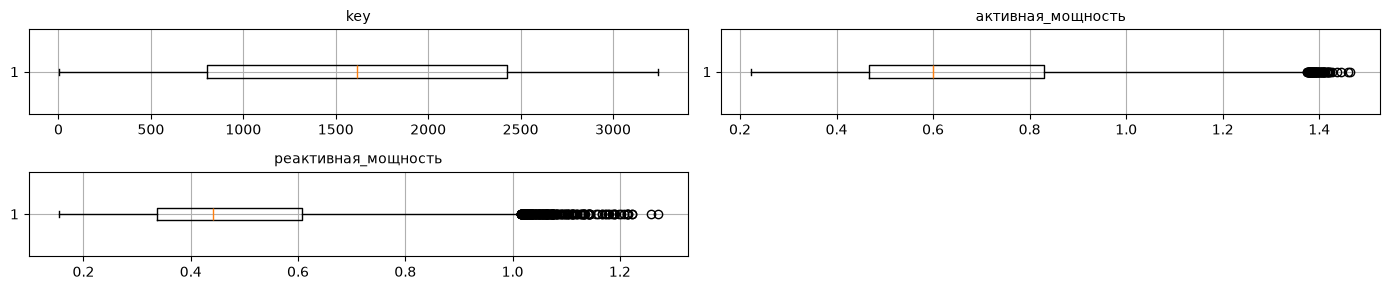

In [160]:
show_all_boxplots(arc)

In [161]:
arc.loc[arc['реактивная_мощность'] > 1.1].tail(3)

,key,начало_нагрева_дугой,конец_нагрева_дугой,активная_мощность,реактивная_мощность
13728,2978,2019-08-28 16:03:02,2019-08-28 16:06:16,1.298187,1.178033
13966,3031,2019-08-30 12:35:40,2019-08-30 12:39:41,1.290343,1.130064
14115,3069,2019-08-31 20:02:33,2019-08-31 20:04:24,1.339945,1.222632


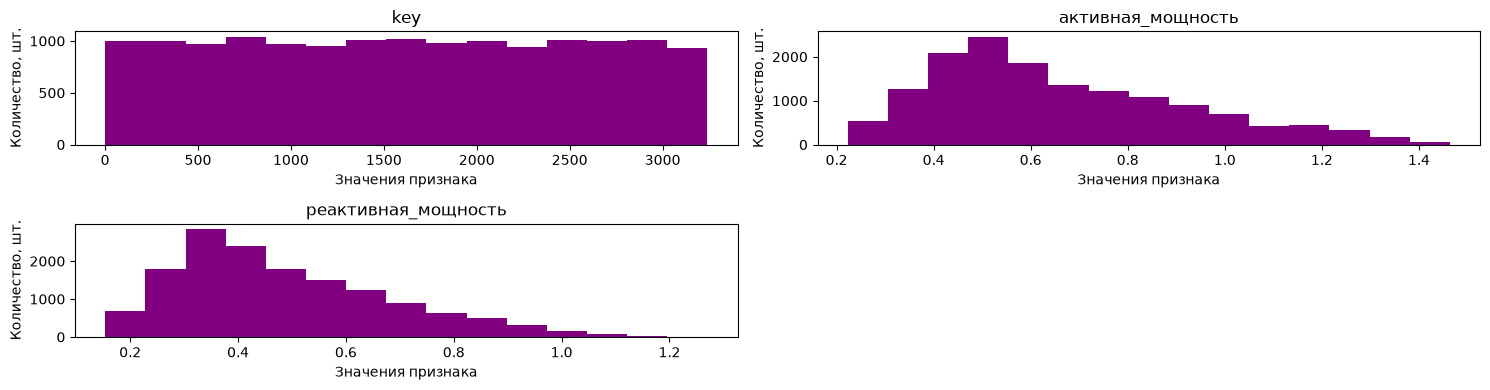

In [162]:
show_all_hists(arc)

In [163]:
print('Количество уникальных ключей:', len(arc['key'].unique()))

Количество уникальных ключей: 3213


In [164]:
arc.loc[arc['key'] == 1]

,key,начало_нагрева_дугой,конец_нагрева_дугой,активная_мощность,реактивная_мощность
0,1,2019-05-03 11:02:14,2019-05-03 11:06:02,0.305130,0.211253
1,1,2019-05-03 11:07:28,2019-05-03 11:10:33,0.765658,0.477438
2,1,2019-05-03 11:11:44,2019-05-03 11:14:36,0.580313,0.430460
3,1,2019-05-03 11:18:14,2019-05-03 11:24:19,0.518496,0.379979
4,1,2019-05-03 11:26:09,2019-05-03 11:28:37,0.867133,0.643691


Выводы:
- Количество объектов совпадает по полям;
- Типы полей соответствует данным, которые они содержат в себе;
- Есть дубликаты внутри поля, но при этом по самим объектам (с учетом нескольких полей) - дубликатов нет, объекты уникальны;
- Было найдено одно аномальное значенеи по реактивной мощности, было принято решение удалить всю партию;
- Распределения полей не являются симметричными и имеют длинный хвост вправо, что для реактивной, что для активной мощностей;
- На диаграмме ящик с усами, есть небольшое количество выбросов, но они находятся прямо за усом и данные находятся достаточно плотно. Предлагается их оставить в датасете как хвост распределения.

---

Можно сделать признаки:
- Количество нагревов;
- Время нагревов;
- Общее время нагрева;
- Можно расчитать полную мощность - S или пойти дальше и расчитать коэффициент мощности - cos_ф (он легко интерпретируемый и безразмерный), таким образом мы уменьшим количество признаков (придется отказаться от реакт и активн мощностей, иначе они буду созависимы от cos_ф или полной мощности;

In [165]:
arc['cos_ф'] = arc['активная_мощность'] / ((arc['активная_мощность'] ** 2 + arc['реактивная_мощность'] ** 2) ** 0.5)

In [166]:
arc['время_нагрева'] = arc['конец_нагрева_дугой'] - arc['начало_нагрева_дугой']
arc['время_нагрева'] = arc['время_нагрева'].dt.seconds
arc['время_нагрева'].tail()

14871    157
14872    180
14873    184
14874     57
14875     81
Name: время_нагрева, dtype: int32

In [167]:
arc['количество_нагревов'] = arc.groupby("key")["key"].transform("count")

In [168]:
arc.head(3)

,key,начало_нагрева_дугой,конец_нагрева_дугой,активная_мощность,реактивная_мощность,cos_ф,время_нагрева,количество_нагревов
0,1,2019-05-03 11:02:14,2019-05-03 11:06:02,0.305130,0.211253,0.822181,228,5
1,1,2019-05-03 11:07:28,2019-05-03 11:10:33,0.765658,0.477438,0.848545,185,5
2,1,2019-05-03 11:11:44,2019-05-03 11:14:36,0.580313,0.430460,0.803161,172,5


In [169]:
arc = (arc.groupby("key", as_index=False).agg({"cos_ф": "mean", "время_нагрева": "sum","количество_нагревов": "first"}))

In [170]:
arc.head(3)

,key,cos_ф,время_нагрева,количество_нагревов
0,1,0.816686,1098,5
1,2,0.825276,811,4
2,3,0.809724,655,5


In [171]:
arc.describe()

,key,cos_ф,время_нагрева,количество_нагревов
count,3213.000000,3213.000000,3213.000000,3213.000000
mean,1622.907874,0.805932,794.691566,4.628696
std,934.844882,0.013941,332.439136,1.608860
min,1.000000,0.739789,57.000000,1.000000
25%,817.000000,0.797305,571.000000,4.000000
50%,1623.000000,0.806424,770.000000,4.000000
75%,2432.000000,0.815581,983.000000,6.000000
max,3241.000000,0.857042,4189.000000,16.000000


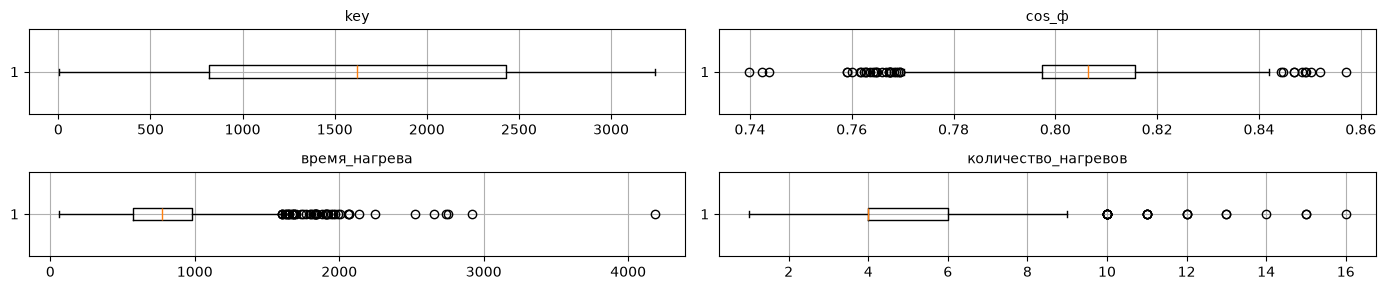

In [172]:
show_all_boxplots(arc)

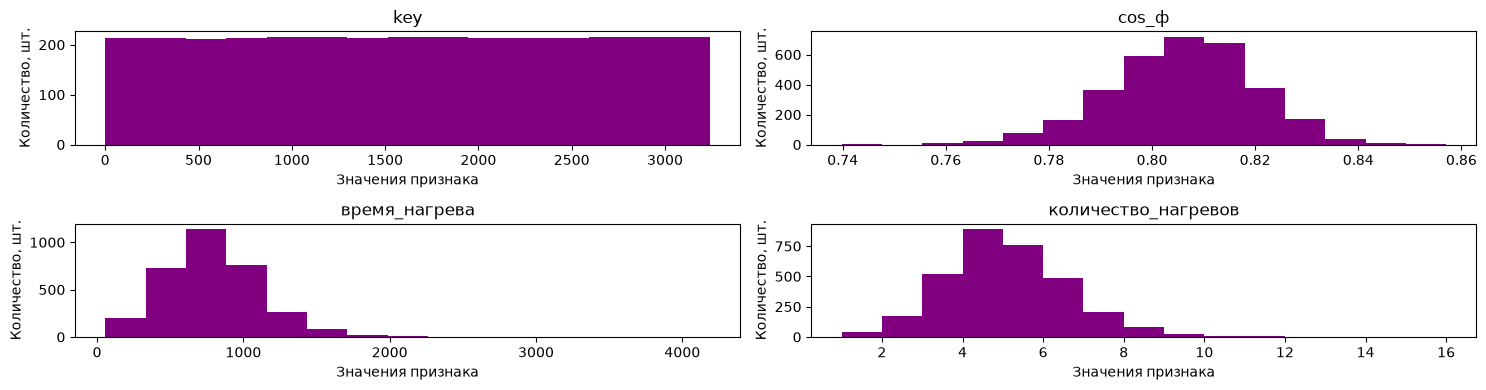

In [173]:
show_all_hists(arc)

In [174]:
arc.loc[arc['время_нагрева'] > 4000]

,key,cos_ф,время_нагрева,количество_нагревов
1672,1689,0.809556,4189,15


In [175]:
arc.loc[arc['время_нагрева'] > 4000, 'время_нагрева'].item()/60/60

1.1636111111111112

Выводы:
- Пересобрали датафрейм из новых признаков, уменьшив их количество с 5 до 4;
- Количество объектов в датафрейме уменьшилось до 3200;
- cos_φ - распределение выглядит примерно нормальным (колоколообразным) и достаточно симметричным. Есть небольшой хвост, но в целом на нормальное похоже;
- Количество_нагревов — не нормальное: явно заметна правосторонняя (положительная) асимметрия — основная масса значений около 4–6, а хвост тянется вправо до ~14;
- Распределение времени нагрева явно правосторонне асимметричное (положительная асимметрия);
- Есть некоторые выбросы, пока принято их не удалять, поскольку нет отличия на порядок числа (общее время нагрева составило около часа);
- Медианные значения достаточно хорошо лежит у cos_ф - ровно по середине, у время_нагрева также лежит четко по центру ящика (сам ящик смещен влево), а вот у количество_нагревов медиана является нижним квартилем Q1;
- время_нагрева и количество_нагревов имеют длинные хвосты распределений;

In [176]:
arc.isna().sum()

key                    0
cos_ф                  0
время_нагрева          0
количество_нагревов    0
dtype: int64

---

### bulk df

Данные об объёме сыпучих материалов:

In [177]:
query = '''
SELECT *
FROM data_bulk;
'''

bulk = pd.read_sql_query(query, con=engine)
bulk.head()

,key,Bulk 1,Bulk 2,Bulk 3,Bulk 4,Bulk 5,Bulk 6,Bulk 7,Bulk 8,Bulk 9,Bulk 10,Bulk 11,Bulk 12,Bulk 13,Bulk 14,Bulk 15
0,1,NaN,NaN,NaN,43.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,206.0,NaN,150.0,154.0
1,2,NaN,NaN,NaN,73.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,206.0,NaN,149.0,154.0
2,3,NaN,NaN,NaN,34.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,205.0,NaN,152.0,153.0
3,4,NaN,NaN,NaN,81.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,207.0,NaN,153.0,154.0
4,5,NaN,NaN,NaN,78.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,203.0,NaN,151.0,152.0


In [178]:
bulk.info()

<class 'pandas.DataFrame'>
RangeIndex: 3129 entries, 0 to 3128
Data columns (total 16 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   key      3129 non-null   int64  
 1   Bulk 1   252 non-null    float64
 2   Bulk 2   22 non-null     float64
 3   Bulk 3   1298 non-null   float64
 4   Bulk 4   1014 non-null   float64
 5   Bulk 5   77 non-null     str    
 6   Bulk 6   576 non-null    str    
 7   Bulk 7   25 non-null     str    
 8   Bulk 8   1 non-null      str    
 9   Bulk 9   19 non-null     str    
 10  Bulk 10  176 non-null    str    
 11  Bulk 11  177 non-null    str    
 12  Bulk 12  2450 non-null   str    
 13  Bulk 13  18 non-null     str    
 14  Bulk 14  2806 non-null   str    
 15  Bulk 15  2248 non-null   str    
dtypes: float64(4), int64(1), str(11)
memory usage: 391.2 KB


In [179]:
bulk.describe()

,key,Bulk 1,Bulk 2,Bulk 3,Bulk 4
count,3129.000000,252.000000,22.000000,1298.000000,1014.000000
mean,1624.383509,39.242063,253.045455,113.879045,104.394477
std,933.337642,18.277654,21.180578,75.483494,48.184126
min,1.000000,10.000000,228.000000,6.000000,12.000000
25%,816.000000,27.000000,242.000000,58.000000,72.000000
50%,1622.000000,31.000000,251.500000,97.500000,102.000000
75%,2431.000000,46.000000,257.750000,152.000000,133.000000
max,3241.000000,185.000000,325.000000,454.000000,281.000000


In [180]:
bulk.columns = bulk.columns.str.lower().str.replace(' ', '_')

In [181]:
bulk.duplicated().sum(), bulk.isnull().sum().sum()

(np.int64(0), np.int64(35776))

In [182]:
bulk.head()

,key,bulk_1,bulk_2,bulk_3,bulk_4,bulk_5,bulk_6,bulk_7,bulk_8,bulk_9,bulk_10,bulk_11,bulk_12,bulk_13,bulk_14,bulk_15
0,1,NaN,NaN,NaN,43.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,206.0,NaN,150.0,154.0
1,2,NaN,NaN,NaN,73.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,206.0,NaN,149.0,154.0
2,3,NaN,NaN,NaN,34.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,205.0,NaN,152.0,153.0
3,4,NaN,NaN,NaN,81.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,207.0,NaN,153.0,154.0
4,5,NaN,NaN,NaN,78.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,203.0,NaN,151.0,152.0


In [183]:
#bulk = bulk.fillna(0)

In [184]:
#bulk = bulk.astype(float).astype(int)
#bulk.isnull().sum().sum()

In [185]:
#bulk.drop(['bulk_1','bulk_2', 'bulk_7','bulk_8', 'bulk_9', 'bulk_10', 'bulk_11', 'bulk_13'], axis= 1 , inplace= True )

In [186]:
bulk["количество_подач_материала"] = bulk.drop('key', axis=1).count(axis=1)
bulk["сумма_материала"] = bulk.drop('key', axis=1).sum(axis=1, numeric_only=True)
bulk["средняя_подача_материала"] = (bulk["сумма_материала"] / bulk["количество_подач_материала"])

In [187]:
bulk = bulk[['key', 'количество_подач_материала', 'сумма_материала', 'средняя_подача_материала']]

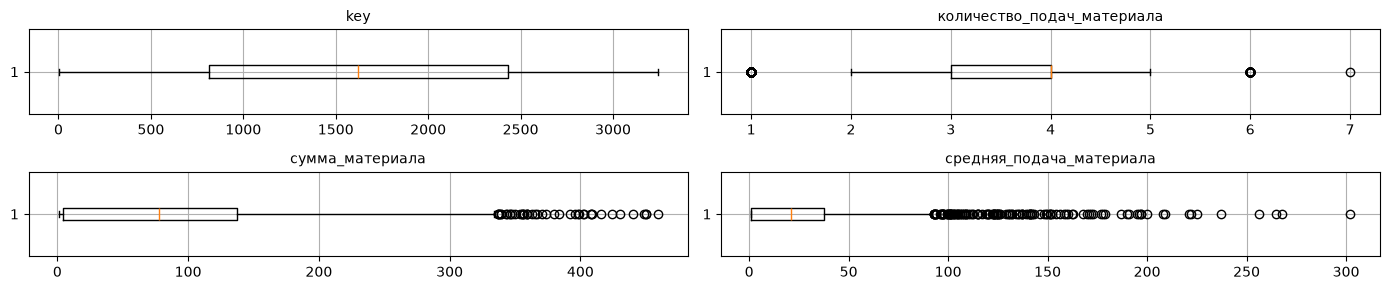

In [188]:
show_all_boxplots(bulk)

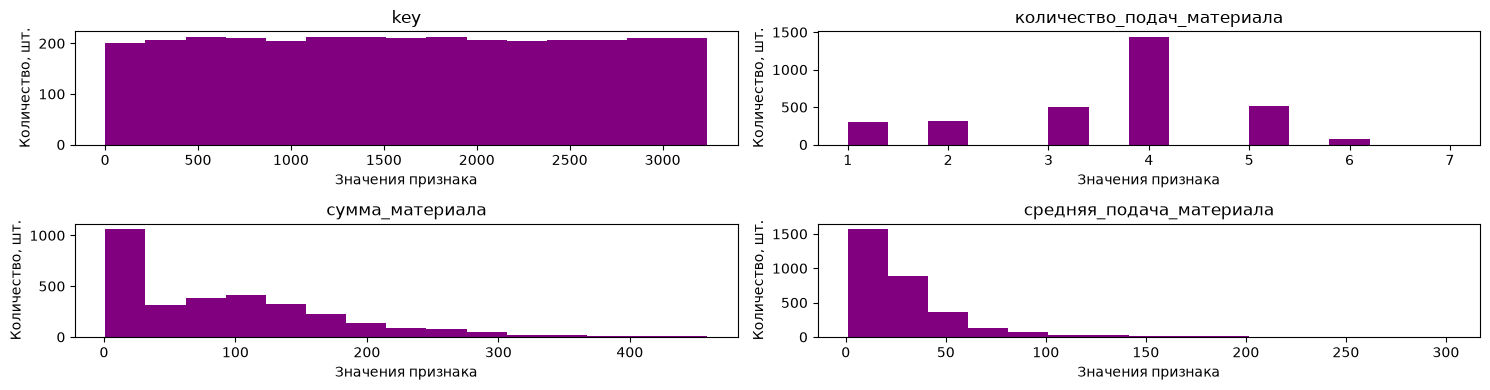

In [189]:
show_all_hists(bulk)

In [190]:
bulk = bulk[['key', 'средняя_подача_материала']]

Выводы:
- Пересобрали датафрейм из новых признаков, сократив количество по тем признакам где были одни нули;
- ~~У нас остались поля bulk_6 и bulk_5 у которых медиана в нуле, при расчете на моделях можно будет поэксперементировать посчитав с этими признаками и без них посмотрев на метрику;~~
- У нас распределение отсечено слево и с большим хвостом вправо.

In [191]:
bulk.isna().sum()

key                         0
средняя_подача_материала    0
dtype: int64

### bulk_time df

Данные о времени подачи сыпучих материалов:

In [192]:
query = '''
SELECT *
FROM data_bulk_time;
'''

bulk_time = pd.read_sql_query(query, con=engine)
bulk_time.head(3)

,key,Bulk 1,Bulk 2,Bulk 3,Bulk 4,Bulk 5,Bulk 6,Bulk 7,Bulk 8,Bulk 9,Bulk 10,Bulk 11,Bulk 12,Bulk 13,Bulk 14,Bulk 15
0,1,NaN,NaN,NaN,2019-05-03 11:28:48,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019-05-03 11:24:31,NaN,2019-05-03 11:14:50,2019-05-03 11:10:43
1,2,NaN,NaN,NaN,2019-05-03 11:36:50,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019-05-03 11:53:30,NaN,2019-05-03 11:48:37,2019-05-03 11:44:39
2,3,NaN,NaN,NaN,2019-05-03 12:32:39,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019-05-03 12:27:13,NaN,2019-05-03 12:21:01,2019-05-03 12:16:16


In [193]:
bulk_time.columns = bulk_time.columns.str.lower().str.replace(' ', '_')

In [194]:
#bulk_time.drop(['bulk_1','bulk_2', 'bulk_7','bulk_8', 'bulk_9', 'bulk_10', 'bulk_11', 'bulk_13'], axis= 1 , inplace= True )

In [195]:
bulk_time.tail(10)

,key,bulk_1,bulk_2,bulk_3,bulk_4,bulk_5,bulk_6,bulk_7,bulk_8,bulk_9,bulk_10,bulk_11,bulk_12,bulk_13,bulk_14,bulk_15
3119,3232,NaN,NaN,2019-09-06 08:43:49,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019-09-06 08:59:18,NaN,2019-09-06 08:54:41,2019-09-06 08:50:40
3120,3233,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019-09-06 09:18:31,NaN,2019-09-06 09:35:02,2019-09-06 09:24:13
3121,3234,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019-09-06 09:51:25,2019-09-06 09:51:25
3122,3235,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019-09-06 10:50:02,NaN,2019-09-06 10:38:19,2019-09-06 10:25:39
3123,3236,NaN,NaN,2019-09-06 11:04:20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019-09-06 11:04:20,NaN,2019-09-06 11:04:20,2019-09-06 11:04:20
3124,3237,NaN,NaN,2019-09-06 11:54:15,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019-09-06 11:49:45,NaN,2019-09-06 11:45:22,2019-09-06 11:40:06
3125,3238,NaN,NaN,2019-09-06 12:26:52,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019-09-06 12:18:35,NaN,2019-09-06 12:31:49,2019-09-06 12:26:52
3126,3239,NaN,NaN,NaN,NaN,NaN,2019-09-06 15:06:00,NaN,NaN,NaN,NaN,NaN,2019-09-06 15:01:44,NaN,2019-09-06 14:58:15,2019-09-06 14:48:06
3127,3240,NaN,NaN,NaN,NaN,NaN,2019-09-06 16:24:28,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019-09-06 16:07:29,2019-09-06 16:01:34
3128,3241,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019-09-06 17:26:33,2019-09-06 17:23:15


In [196]:
for i in bulk_time.columns:
    if i == 'key':
        continue
    else:
        bulk_time[i] = pd.to_datetime(bulk_time[i])

In [197]:
bulk_time.info()

<class 'pandas.DataFrame'>
RangeIndex: 3129 entries, 0 to 3128
Data columns (total 16 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   key      3129 non-null   int64         
 1   bulk_1   252 non-null    datetime64[us]
 2   bulk_2   22 non-null     datetime64[us]
 3   bulk_3   1298 non-null   datetime64[us]
 4   bulk_4   1014 non-null   datetime64[us]
 5   bulk_5   77 non-null     datetime64[us]
 6   bulk_6   576 non-null    datetime64[us]
 7   bulk_7   25 non-null     datetime64[us]
 8   bulk_8   1 non-null      datetime64[us]
 9   bulk_9   19 non-null     datetime64[us]
 10  bulk_10  176 non-null    datetime64[us]
 11  bulk_11  177 non-null    datetime64[us]
 12  bulk_12  2450 non-null   datetime64[us]
 13  bulk_13  18 non-null     datetime64[us]
 14  bulk_14  2806 non-null   datetime64[us]
 15  bulk_15  2248 non-null   datetime64[us]
dtypes: datetime64[us](15), int64(1)
memory usage: 391.2 KB


In [198]:
bulk_time['мин_время'] = bulk_time.drop(columns='key').min(axis=1)
bulk_time['макс_время'] = bulk_time.drop(columns='key').max(axis=1)

In [199]:
bulk_time["время_загрузки_материала"] = (bulk_time["макс_время"] - bulk_time["мин_время"])
bulk_time["время_загрузки_материала"] = bulk_time["время_загрузки_материала"].dt.seconds

У некоторых подач материала одинаковое время - возможно их подавали одновременно.
Предлагается для эксперимента оставить объекты с нулевым временем подачи.

In [200]:
bulk_time = bulk_time[['key', 'время_загрузки_материала']]

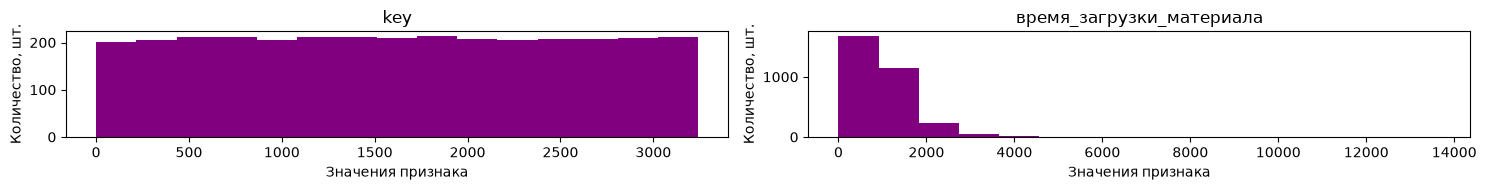

In [201]:
show_all_hists(bulk_time)

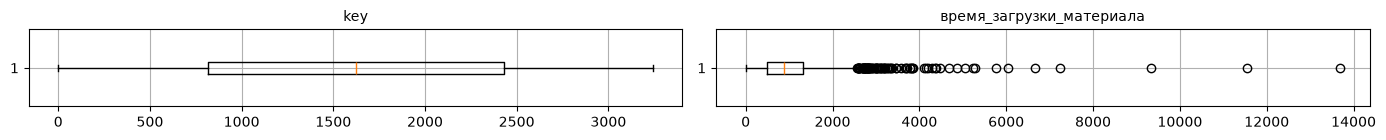

In [202]:
show_all_boxplots(bulk_time)

In [203]:
bulk_time.loc[bulk_time['время_загрузки_материала'] > 10000]['время_загрузки_материала']/60/60

1819    3.208889
1895    3.800833
Name: время_загрузки_материала, dtype: float64

~3 часа - скорее является хвостом распределения чем реальной аномалией.

In [204]:
bulk_time.isna().sum()

key                         0
время_загрузки_материала    0
dtype: int64

### gas df

In [205]:
query = '''
SELECT *
FROM data_gas;
'''

gas = pd.read_sql_query(query, con=engine)
gas.head()

,key,Газ 1
0,1,29.749986
1,2,12.555561
2,3,28.554793
3,4,18.841219
4,5,5.413692


In [206]:
gas.columns = gas.columns.str.lower().str.replace(' ', '_')

In [207]:
gas.duplicated().sum()

np.int64(0)

In [208]:
gas.isna().sum()

key      0
газ_1    0
dtype: int64

In [209]:
gas.info()

<class 'pandas.DataFrame'>
RangeIndex: 3239 entries, 0 to 3238
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   key     3239 non-null   int64  
 1   газ_1   3239 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 50.7 KB


In [210]:
gas.describe()

,key,газ_1
count,3239.000000,3239.000000
mean,1621.861377,11.002062
std,935.386334,6.220327
min,1.000000,0.008399
25%,812.500000,7.043089
50%,1622.000000,9.836267
75%,2431.500000,13.769915
max,3241.000000,77.995040


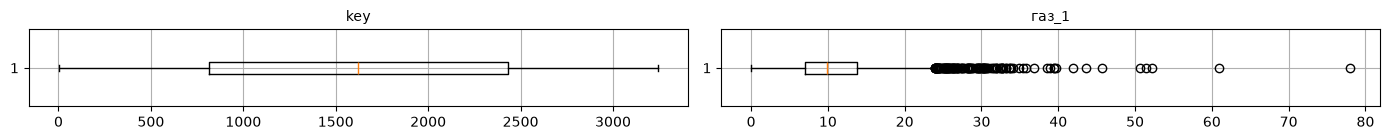

In [211]:
show_all_boxplots(gas)

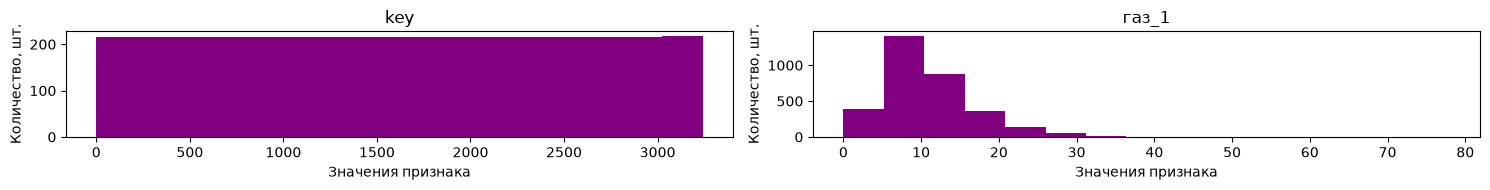

In [212]:
show_all_hists(gas)

In [213]:
gas.loc[gas['газ_1'] > 75]

,key,газ_1
319,322,77.99504


Выводы:
- Поля по наполненности равны друг другу, пропусков нет;
- Типы полей соответствуют данным, которые они содержат;
- Дубликатов - нет;
- У нас распределение отсечено слево и с большим хвостом вправо, ассиметрично;
- Имеется хвост распределения с выбросами около 80 м3 газа, что похоже на правду;

In [214]:
gas.isna().sum()

key      0
газ_1    0
dtype: int64

---

### temp df

In [215]:
query = '''
SELECT *
FROM data_temp;
'''

temp = pd.read_sql_query(query, con=engine)
temp.head(7)

,key,Время замера,Температура
0,1,2019-05-03 11:02:04,1571.0
1,1,2019-05-03 11:07:18,1604.0
2,1,2019-05-03 11:11:34,1618.0
3,1,2019-05-03 11:18:04,1601.0
4,1,2019-05-03 11:25:59,1606.0
5,1,2019-05-03 11:30:38,1613.0
6,2,2019-05-03 11:34:04,1581.0


In [216]:
temp.loc[temp['key'] == 3000]

,key,Время замера,Температура
16804,3000,2019-08-29 09:48:33,1609.0
16805,3000,2019-08-29 09:53:47,NaN
16806,3000,2019-08-29 10:00:59,NaN
16807,3000,2019-08-29 10:06:16,NaN


Нам необходимо избавиться от тех партий (key) в которых была только одна замеренная температура и нет конечной целевой: 

In [217]:
temp_keys = temp.groupby('key')['Температура'].count()
keys_one_temp = temp_keys[temp_keys == 1].index
temp = temp.loc[~temp['key'].isin(keys_one_temp)]

In [218]:
temp.loc[temp['Температура'].isna() == True]

,key,Время замера,Температура


In [219]:
temp.info()

<class 'pandas.DataFrame'>
Index: 13924 entries, 0 to 13925
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   key           13924 non-null  int64
 1   Время замера  13924 non-null  str  
 2   Температура   13924 non-null  str  
dtypes: int64(1), str(2)
memory usage: 435.1 KB


In [220]:
temp.columns = temp.columns.str.lower().str.replace(' ', '_')

In [221]:
temp['время_замера'] = pd.to_datetime(temp['время_замера'])

In [222]:
temp.isna().sum()

key             0
время_замера    0
температура     0
dtype: int64

In [223]:
temp = temp.dropna()

In [224]:
temp.duplicated().sum()

np.int64(0)

In [225]:
temp['температура'] = temp['температура'].astype('float').astype('int')

In [226]:
temp.head(7)

,key,время_замера,температура
0,1,2019-05-03 11:02:04,1571
1,1,2019-05-03 11:07:18,1604
2,1,2019-05-03 11:11:34,1618
3,1,2019-05-03 11:18:04,1601
4,1,2019-05-03 11:25:59,1606
5,1,2019-05-03 11:30:38,1613
6,2,2019-05-03 11:34:04,1581


In [227]:
temp = temp.sort_values(["key", "время_замера"])

In [228]:
temp = (
    temp.groupby("key", as_index=False)
        .agg(
            время_замера_min=("время_замера", "min"),
            время_замера_max=("время_замера", "max"),
            температура_начальная=("температура", "first"),
            температура_конечная=("температура", "last")
        )
)

In [229]:
temp.head(7)

,key,время_замера_min,время_замера_max,температура_начальная,температура_конечная
0,1,2019-05-03 11:02:04,2019-05-03 11:30:38,1571,1613
1,2,2019-05-03 11:34:04,2019-05-03 11:55:09,1581,1602
2,3,2019-05-03 12:06:44,2019-05-03 12:35:57,1596,1599
3,4,2019-05-03 12:39:27,2019-05-03 12:59:47,1601,1625
4,5,2019-05-03 13:11:03,2019-05-03 13:36:39,1576,1602
5,6,2019-05-03 13:46:41,2019-05-03 14:11:38,1543,1596
6,7,2019-05-03 14:16:36,2019-05-03 14:45:40,1586,1599


In [230]:
temp['общее_время_нагрева'] = temp['время_замера_max'] - temp['время_замера_min']
temp['общее_время_нагрева'] = temp['общее_время_нагрева'].dt.seconds
temp = temp[['key', 'общее_время_нагрева', 'температура_начальная','температура_конечная']]

In [231]:
temp = temp.loc[temp['температура_начальная'] > 1500]
temp = temp.loc[temp['температура_конечная'] > 1500]

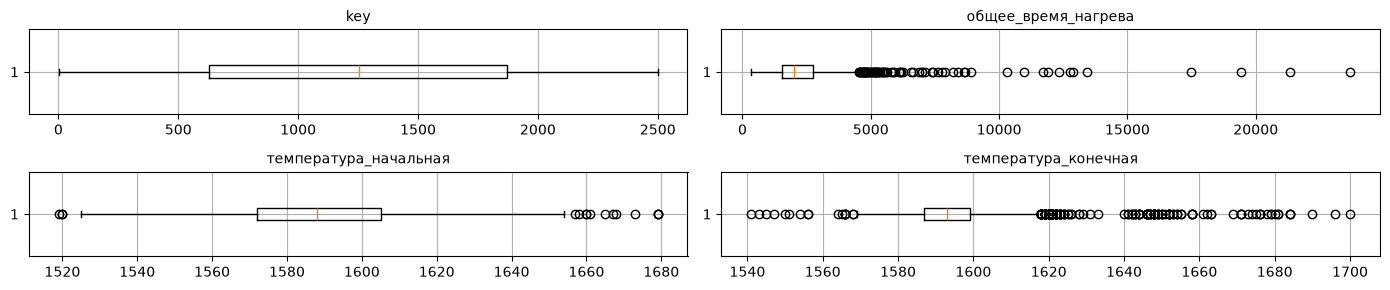

In [232]:
show_all_boxplots(temp)

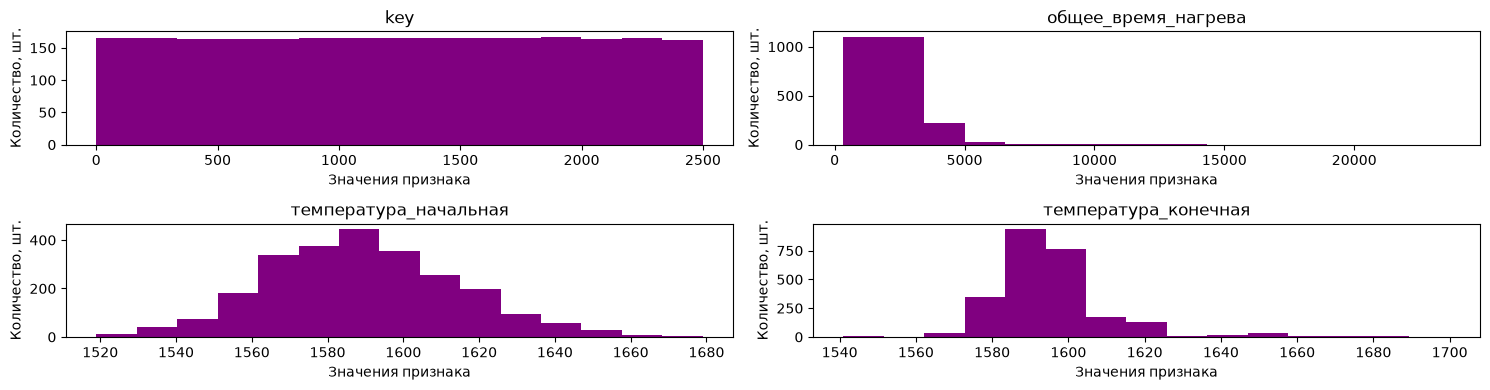

In [233]:
show_all_hists(temp)

Выводы:
- Начальная температура имеет распределения близкое к нормальному;
- Конечная температура выглядит ассеметрично; 
- Общее время нагрева сдвинуто влево;
- Сделали несколько признаков;

In [234]:
temp.isna().sum()

key                      0
общее_время_нагрева      0
температура_начальная    0
температура_конечная     0
dtype: int64

---

### wire df

In [235]:
query = '''
SELECT *
FROM data_wire;
'''

wire = pd.read_sql_query(query, con=engine)
wire.head()

,key,Wire 1,Wire 2,Wire 3,Wire 4,Wire 5,Wire 6,Wire 7,Wire 8,Wire 9
0,1,60.059998,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,96.052315,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,91.160157,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,89.063515,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,89.238236,9.11456,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [236]:
wire.columns = wire.columns.str.lower().str.replace(' ', '_')

In [237]:
wire.duplicated().sum()

np.int64(0)

In [238]:
wire.isna().sum()

key          0
wire_1      26
wire_2    2002
wire_3    3018
wire_4    3067
wire_5    3080
wire_6    3008
wire_7    3070
wire_8    3062
wire_9    3052
dtype: int64

In [239]:
wire["количество_проволок"] = wire.drop('key', axis=1).count(axis=1)
wire["сумма_проволки"] = wire.drop('key', axis=1).sum(axis=1, numeric_only=True)
wire["средняя_подача_проволки"] = (wire["сумма_проволки"] / wire["количество_проволок"])

In [240]:
wire.head()

,key,wire_1,wire_2,wire_3,wire_4,wire_5,wire_6,wire_7,wire_8,wire_9,количество_проволок,сумма_проволки,средняя_подача_проволки
0,1,60.059998,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,61.059998,61.059998
1,2,96.052315,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,97.052315,97.052315
2,3,91.160157,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,92.160157,92.160157
3,4,89.063515,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,90.063515,90.063515
4,5,89.238236,9.11456,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,91.238236,45.619118


In [241]:
wire = wire[['key', 'средняя_подача_проволки']]

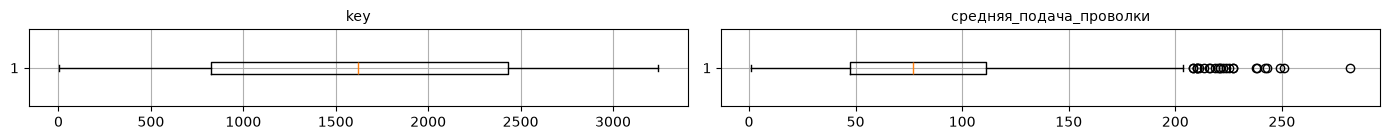

In [242]:
show_all_boxplots(wire)

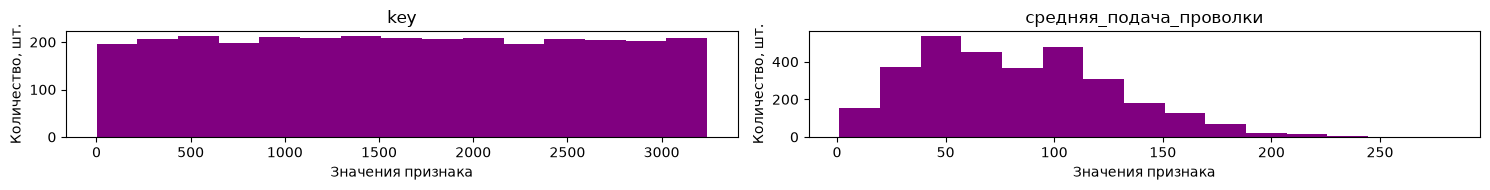

In [243]:
show_all_hists(wire)

Выводы:
- Сделали один новый признак заместо нескольких;
- У средней подачи ассиметричное распеределние со сдвигом влево и длинным хвостом в правой части;
- Пропусков и дубликатов нет;
- Типы полей соответствуют наполненным данным;

In [244]:
wire.isna().sum()

key                        0
средняя_подача_проволки    0
dtype: int64

---

### wire_time df

In [245]:
query = '''
SELECT *
FROM data_wire_time;
'''

wire_time = pd.read_sql_query(query, con=engine)
wire_time.head()

,key,Wire 1,Wire 2,Wire 3,Wire 4,Wire 5,Wire 6,Wire 7,Wire 8,Wire 9
0,1,2019-05-03 11:06:19,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,2019-05-03 11:36:50,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,2019-05-03 12:11:46,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,2019-05-03 12:43:22,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,2019-05-03 13:20:44,2019-05-03 13:15:34,NaN,NaN,NaN,NaN,NaN,NaN,NaN


C wire_time стратегия будет такой же как с bulk time

In [246]:
wire_time.columns = wire_time.columns.str.lower().str.replace(' ', '_')

In [247]:
for i in wire_time.columns:
    if i == 'key':
        continue
    else:
        wire_time[i] = pd.to_datetime(wire_time[i])

In [248]:
wire_time['мин_время'] = wire_time.drop(columns='key').min(axis=1)
wire_time['макс_время'] = wire_time.drop(columns='key').max(axis=1)

In [249]:
wire_time.head()

,key,wire_1,wire_2,wire_3,wire_4,wire_5,wire_6,wire_7,wire_8,wire_9,мин_время,макс_время
0,1,2019-05-03 11:06:19,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,2019-05-03 11:06:19,2019-05-03 11:06:19
1,2,2019-05-03 11:36:50,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,2019-05-03 11:36:50,2019-05-03 11:36:50
2,3,2019-05-03 12:11:46,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,2019-05-03 12:11:46,2019-05-03 12:11:46
3,4,2019-05-03 12:43:22,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,2019-05-03 12:43:22,2019-05-03 12:43:22
4,5,2019-05-03 13:20:44,2019-05-03 13:15:34,NaT,NaT,NaT,NaT,NaT,NaT,NaT,2019-05-03 13:15:34,2019-05-03 13:20:44


In [250]:
wire_time["время_загрузки_проволки"] = (wire_time["макс_время"] - wire_time["мин_время"])
wire_time["время_загрузки_проволки"] = wire_time["время_загрузки_проволки"].dt.seconds

In [251]:
wire_time = wire_time[['key', 'время_загрузки_проволки']]

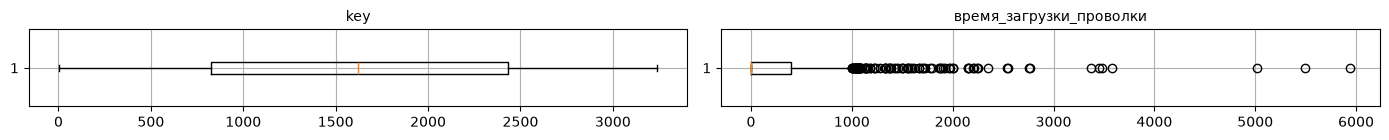

In [252]:
show_all_boxplots(wire_time)

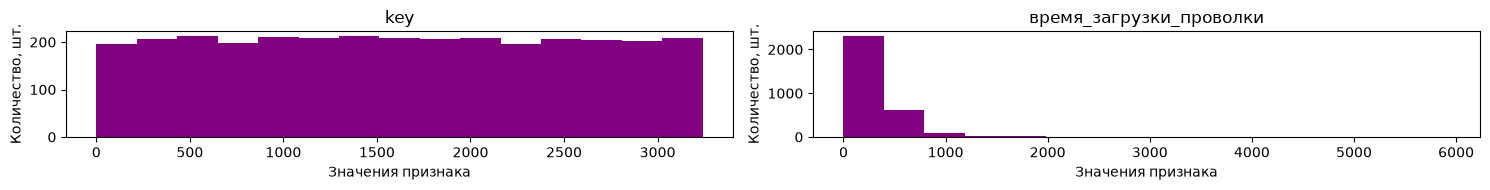

In [253]:
show_all_hists(wire_time)

In [254]:
wire_time.isna().sum()

key                        0
время_загрузки_проволки    0
dtype: int64

## Объединение

In [255]:
print(
arc["key"].duplicated().sum(),
bulk["key"].duplicated().sum(),
bulk_time["key"].duplicated().sum(),
gas["key"].duplicated().sum(),
temp["key"].duplicated().sum(),
wire["key"].duplicated().sum(),
wire_time["key"].duplicated().sum())

0 0 0 0 0 0 0


In [256]:
dfs = [bulk, bulk_time, arc, gas, temp, wire, wire_time]

In [257]:
df = reduce(lambda left, right: pd.merge(left, right, on="key", how="inner"), dfs)

In [258]:
df.head()

,key,средняя_подача_материала,время_загрузки_материала,cos_ф,время_нагрева,количество_нагревов,газ_1,общее_время_нагрева,температура_начальная,температура_конечная,средняя_подача_проволки,время_загрузки_проволки
0,1,11.75,1085,0.816686,1098,5,29.749986,1714,1571,1613,61.059998,0
1,2,19.25,1000,0.825276,811,4,12.555561,1265,1581,1602,97.052315,0
2,3,9.50,983,0.809724,655,5,28.554793,1753,1596,1599,92.160157,0
3,4,21.25,878,0.793923,741,4,18.841219,1220,1601,1625,90.063515,0
4,5,20.50,205,0.796818,869,4,5.413692,1536,1576,1602,45.619118,310


In [259]:
df

,key,средняя_подача_материала,время_загрузки_материала,cos_ф,время_нагрева,количество_нагревов,газ_1,общее_время_нагрева,температура_начальная,температура_конечная,средняя_подача_проволки,время_загрузки_проволки
0,1,11.75,1085,0.816686,1098,5,29.749986,1714,1571,1613,61.059998,0
1,2,19.25,1000,0.825276,811,4,12.555561,1265,1581,1602,97.052315,0
2,3,9.50,983,0.809724,655,5,28.554793,1753,1596,1599,92.160157,0
3,4,21.25,878,0.793923,741,4,18.841219,1220,1601,1625,90.063515,0
4,5,20.50,205,0.796818,869,4,5.413692,1536,1576,1602,45.619118,310
...,...,...,...,...,...,...,...,...,...,...,...,...
2319,2495,5.20,1002,0.812727,723,4,7.125735,1380,1570,1591,90.150879,0
2320,2496,13.60,1171,0.819606,940,6,9.412616,1705,1554,1591,115.179527,0
2321,2497,22.25,668,0.827613,569,3,6.271699,962,1571,1589,48.043362,340
2322,2498,19.00,820,0.819245,750,5,14.953657,1520,1591,1594,119.110717,0


Для поиска зависимостей-созависимостей между признаками будем использовать расчет корреляции методом Спирмена поскольку большинство наших полей-признаков распределены ассиметрично, со сдвигами и длинными "хвостами" распределений.

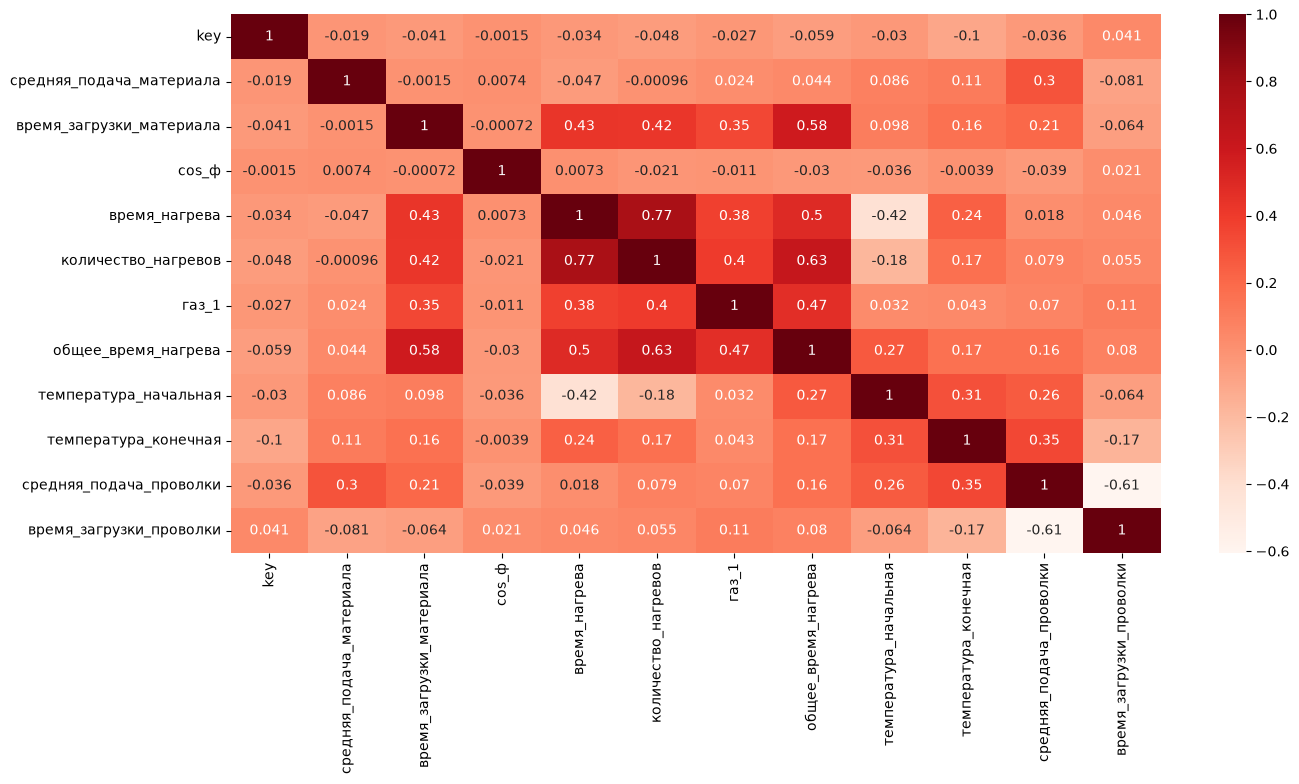

In [260]:
plt.rcParams['figure.figsize'] = [15, 7]
sns.heatmap(df.corr(method='spearman'),
           cmap="Reds", annot=True)

plt.show()

- Есть средние значения мультиколлинеарности между количеством нагревов и времени нагрева (критично для бейзлайн модели линейной регрессии);

- Есть обратная слабая корреляция у общего времени нагрева с ключом, средней подачи проволки и времени загрузки проволки (ключ мы отбросим, это не признак);
- Есть слабая корреляция между температурой начальной и конечной;

## Подготовка выборок

In [261]:
X = df.drop(columns=['температура_конечная', 'key'])
y = df['температура_конечная']


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=RANDOM_STATE)

In [262]:
X_train.isna().sum().sort_values(ascending=False)

средняя_подача_материала    0
время_загрузки_материала    0
cos_ф                       0
время_нагрева               0
количество_нагревов         0
газ_1                       0
общее_время_нагрева         0
температура_начальная       0
средняя_подача_проволки     0
время_загрузки_проволки     0
dtype: int64

## Стандартизация

In [263]:
scaler_X = StandardScaler()

In [264]:
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

## Работа с моделями

### Запуск на тренировочной выборке

#### Baseline модель линейной регрессии

In [265]:
LR_model = LinearRegression()

LR_model.fit(X_train_scaled, y_train)

y_train_pred = LR_model.predict(X_train_scaled)
LR_train_mae = mean_absolute_error(y_train, y_train_pred)

cv_mae = -cross_val_score(
    LR_model,
    X_train_scaled,
    y_train,
    cv=5,
    scoring='neg_mean_absolute_error'
)

print(f"MAE на обучающей выборке: {LR_train_mae:.2f}")
print(f"CV MAE: {cv_mae.mean():.2f} ± {cv_mae.std():.2f}")

MAE на обучающей выборке: 6.20
CV MAE: 6.26 ± 0.10


#### RandomForestRegressor

In [266]:
RFR_model = RandomForestRegressor()
params = {
    'n_estimators': [5, 10, 25, 50],
    'max_depth': [4, 8, 15, 20],
    'min_samples_split': [2, 4, 8],
    'bootstrap': [True, False],
    'random_state': [RANDOM_STATE]
}
RFR_grid = RandomizedSearchCV(RFR_model, params, cv=5, scoring='neg_mean_absolute_error')
RFR_grid.fit(X_train_scaled, y_train)

result_rf = abs(RFR_grid.best_score_)
print(f'MAE на тренировочной: {result_rf:.2f}')

MAE на тренировочной: 6.51


#### CatBoostRegressor

In [267]:
CBR_model = CatBoostRegressor(verbose=False)

params = {
    'loss_function': ['MAE'],
    'depth': [4, 6, 8, 10],
    'learning_rate': [0.03, 0.1],
    'n_estimators': [50, 100, 150],
    'l2_leaf_reg': [1, 3, 5],
    'random_strength': [0, 1],
    'bagging_temperature': [0, 1]}

CBR_grid = RandomizedSearchCV(
    CBR_model,
    params,
    n_iter=20,
    cv=5,
    verbose=2,
    scoring='neg_mean_absolute_error',
    random_state=RANDOM_STATE,
    n_jobs=-1)

CBR_grid.fit(X_train_scaled, y_train)

result_cb = abs(CBR_grid.best_score_)
print(f'MAE на тренировочной: {result_cb:.2f}')

Fitting 5 folds for each of 20 candidates, totalling 100 fits
MAE на тренировочной: 6.24


#### Нейросетевая модель

Необходимо выделить validation из train.

In [268]:
X_train_nn, X_valid_nn, y_train_nn, y_valid_nn = train_test_split(
    X_train_scaled,
    y_train,
    test_size=0.2,
    random_state=RANDOM_STATE)

In [269]:
X_train_tensor = torch.FloatTensor(X_train_nn)
X_valid_tensor = torch.FloatTensor(X_valid_nn)

y_train_tensor = torch.FloatTensor(y_train_nn.values)
y_valid_tensor = torch.FloatTensor(y_valid_nn.values)

In [270]:
class Net(torch.nn.Module):
    def __init__(self, n_features):
        super().__init__()

        self.layers = torch.nn.Sequential(
    torch.nn.Linear(n_features, 32),
    torch.nn.ReLU(),
    torch.nn.Linear(32, 16),
    torch.nn.ReLU(),
    torch.nn.Linear(16, 1)
)

    def forward(self, x):
        return self.layers(x)
    
def init_weights(layer):
    if type(layer) == nn.Linear: # Проверка, что слой – полносвязный
        nn.init.kaiming_uniform_(layer.weight, mode='fan_in', nonlinearity='relu')

In [271]:
n_in = X_train_tensor.size(dim=1)
n_in

10

In [272]:
n_in_neurons = n_in 

first_net = Net(n_in_neurons)

first_net.apply(init_weights)
optimizer = torch.optim.Adam(
    first_net.parameters(),
    lr=0.0001)
loss = torch.nn.L1Loss()

num_epochs = 10000
accumulation_iteration = 5
batch_size = 600
num_batches = ceil(len(X_train_tensor)/batch_size)
nn_mae = float('inf')
patience = 5          
counter = 0
best_weights = None

In [273]:
print(first_net)
print(X_train_tensor.shape)
print(y_train_tensor.shape)
print(first_net(X_train_tensor).shape)

Net(
  (layers): Sequential(
    (0): Linear(in_features=10, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=1, bias=True)
  )
)
torch.Size([1394, 10])
torch.Size([1394])
torch.Size([1394, 1])


In [274]:
for epoch in range(num_epochs):
    order = np.random.permutation(len(X_train_tensor))  
    first_net.train()
    
    for batch_i in range(num_batches):
        start_index = batch_i * batch_size
        batch_indexes = order[start_index:start_index+batch_size]
        
        X_batch = X_train_tensor[batch_indexes]
        y_batch = y_train_tensor[batch_indexes]
        
        preds = first_net(X_batch).flatten()
        
        loss_value = loss(preds, y_batch)
        loss_value.backward()

        if ((batch_i+1) % accumulation_iteration == 0) or (batch_i+1 == num_batches):
            optimizer.step()
            optimizer.zero_grad()
    
    
    first_net.eval()
    
    with torch.no_grad():
        valid_preds = first_net(X_valid_tensor).flatten()
    
    valid_mae = mean_absolute_error(
        y_valid_tensor.numpy(),
        valid_preds.numpy())

    print(
        f'Эпоха: {epoch}, '
        f'Loss: {loss_value.item():.4f}, '
        f'Validation MAE: {valid_mae:.4f}')
    
    if valid_mae < nn_mae:
        nn_mae = valid_mae
        counter = 0
        best_weights = first_net.state_dict().copy()

    else:
        counter += 1

        if counter >= patience:
            print(f'Остановка обучения на эпохе {epoch}')
            break

Эпоха: 0, Loss: 1593.1296, Validation MAE: 1592.5352
Эпоха: 1, Loss: 1593.0006, Validation MAE: 1592.5273
Эпоха: 2, Loss: 1592.7585, Validation MAE: 1592.5197
Эпоха: 3, Loss: 1592.1113, Validation MAE: 1592.5118
Эпоха: 4, Loss: 1592.7213, Validation MAE: 1592.5042
Эпоха: 5, Loss: 1593.6410, Validation MAE: 1592.4965
Эпоха: 6, Loss: 1592.8093, Validation MAE: 1592.4885
Эпоха: 7, Loss: 1592.6018, Validation MAE: 1592.4810
Эпоха: 8, Loss: 1591.8446, Validation MAE: 1592.4731
Эпоха: 9, Loss: 1591.8054, Validation MAE: 1592.4652
Эпоха: 10, Loss: 1592.4778, Validation MAE: 1592.4575
Эпоха: 11, Loss: 1592.7076, Validation MAE: 1592.4498
Эпоха: 12, Loss: 1590.6644, Validation MAE: 1592.4424
Эпоха: 13, Loss: 1591.7903, Validation MAE: 1592.4344
Эпоха: 14, Loss: 1592.2203, Validation MAE: 1592.4266
Эпоха: 15, Loss: 1591.8462, Validation MAE: 1592.4191
Эпоха: 16, Loss: 1591.5232, Validation MAE: 1592.4110
Эпоха: 17, Loss: 1593.9385, Validation MAE: 1592.4033
Эпоха: 18, Loss: 1592.9567, Validation

In [275]:
first_net.load_state_dict(best_weights)
first_net.eval()

with torch.no_grad():
    y_train_pred_nn = first_net(
        X_train_tensor
    ).flatten().numpy()

mae_nn_train = mean_absolute_error(
    y_train_tensor.numpy(),
    y_train_pred_nn)


### Общие результаты на train'e

In [276]:
results_train = pd.DataFrame({
    'Модель': [
        'Linear Regression',
        'CatBoost',
        'Random Forest',
        'Neural Network'
    ],
    'MAE Train': [
        cv_mae.mean(),
        result_cb,
        result_rf,
        mae_nn_train
    ]
})

results_train['MAE Train'] = results_train['MAE Train'].round(2)

results_train = results_train.sort_values(
    'MAE Train'
).reset_index(drop=True)

results_train

,Модель,MAE Train
0,CatBoost,6.24
1,Linear Regression,6.26
2,Random Forest,6.51
3,Neural Network,362.51


- По результатам кросс-валидации на обучающей выборке лучший результат показала модель **CatBoost со средним MAE 6.24°C**. При этом **Linear Regression практически не уступает — её средний MAE по пяти фолдам составил 6.26°C**. Разница между двумя моделями составляет всего 0.02°C, поэтому по данному показателю их качество можно считать практически одинаковым.

- **Random Forest показал несколько более высокую ошибку — 6.45°C**, уступив CatBoost на 0.21°C. Тем не менее разрыв также относительно небольшой, поэтому модель остаётся конкурентоспособной.

- Наиболее слабый результат продемонстрировала **Neural Network — MAE 544.51°C**. Это существенно хуже остальных моделей и указывает на то, что в текущей конфигурации нейросеть не смогла корректно обучиться на задаче прогнозирования конечной температуры.

### Запуск на тестовой выборке

In [277]:
best_cb = CBR_grid.best_estimator_

y_test_pred_cb = best_cb.predict(X_test_scaled)

mae_cb = mean_absolute_error(y_test, y_test_pred_cb)
r2_cb = r2_score(y_test, y_test_pred_cb)

print(f"CV MAE: {-CBR_grid.best_score_:.2f}")
print(f"TEST MAE: {mae_cb:.2f}")
print(f"TEST R²: {r2_cb:.4f}")

CV MAE: 6.24
TEST MAE: 6.19
TEST R²: 0.3948


## Анализ результатов

In [278]:
importance_cb = pd.Series(
    best_cb.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(f"MAE: {mae_cb:.2f}")
print(f"R²: {r2_cb:.4f}")
print(importance_cb)

residuals_cb = y_test - y_test_pred_cb

print(f"Средний остаток: {residuals_cb.mean():.2f}")
print(f"Дисперсия остатков: {residuals_cb.var():.2f}")
print(f"Стандартное отклонение остатков: {residuals_cb.std():.2f}")

MAE: 6.19
R²: 0.3948
время_нагрева               32.353881
температура_начальная       27.611475
средняя_подача_проволки     12.681171
общее_время_нагрева         10.798926
время_загрузки_материала     4.148208
cos_ф                        3.392163
газ_1                        3.046283
время_загрузки_проволки      2.521255
средняя_подача_материала     2.105568
количество_нагревов          1.341070
dtype: float64
Средний остаток: 0.64
Дисперсия остатков: 74.02
Стандартное отклонение остатков: 8.60


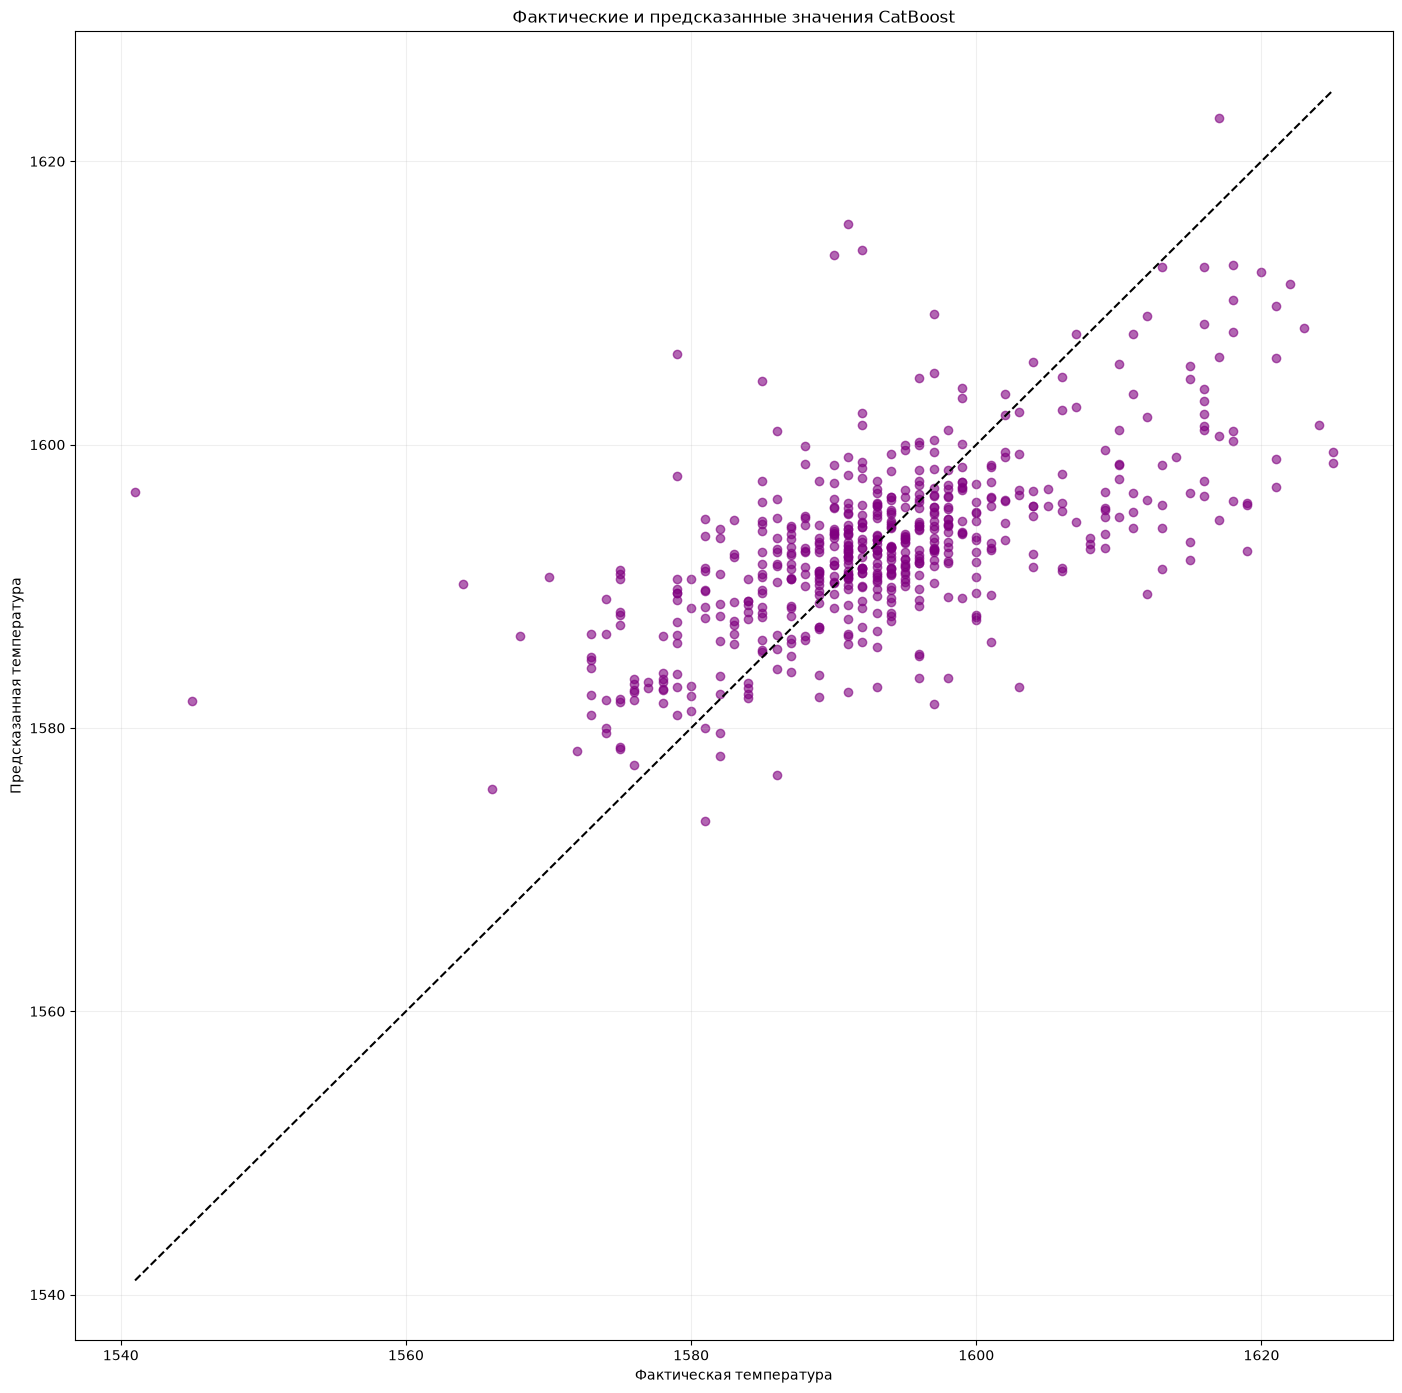

In [279]:
plt.figure(figsize=(17, 17))
plt.scatter(y_test, y_test_pred_cb, alpha=0.6, color='purple')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--', color='black')
plt.xlabel('Фактическая температура')
plt.ylabel('Предсказанная температура')
plt.title('Фактические и предсказанные значения CatBoost')
plt.grid(alpha=0.2)
plt.show()

- На графике фактических и предсказанных значений наблюдается достаточно широкое облако точек, при этом значительная часть предсказаний сосредоточена в области около 1600 °C. Точки не выстраиваются вдоль диагональной линии идеального прогноза, что говорит о наличии заметной ошибки прогнозирования для отдельных партий.

- При значениях фактической температуры, близких к среднему уровню, модель показывает более стабильные прогнозы. Однако на краях диапазона температуры наблюдается более значительное рассеивание точек и присутствуют отдельные наблюдения с большими отклонениями от линии идеального прогноза. Это свидетельствует о том, что Linear Regression хуже предсказывает экстремальные значения температуры и стремится прогнозировать значения, близкие к среднему.

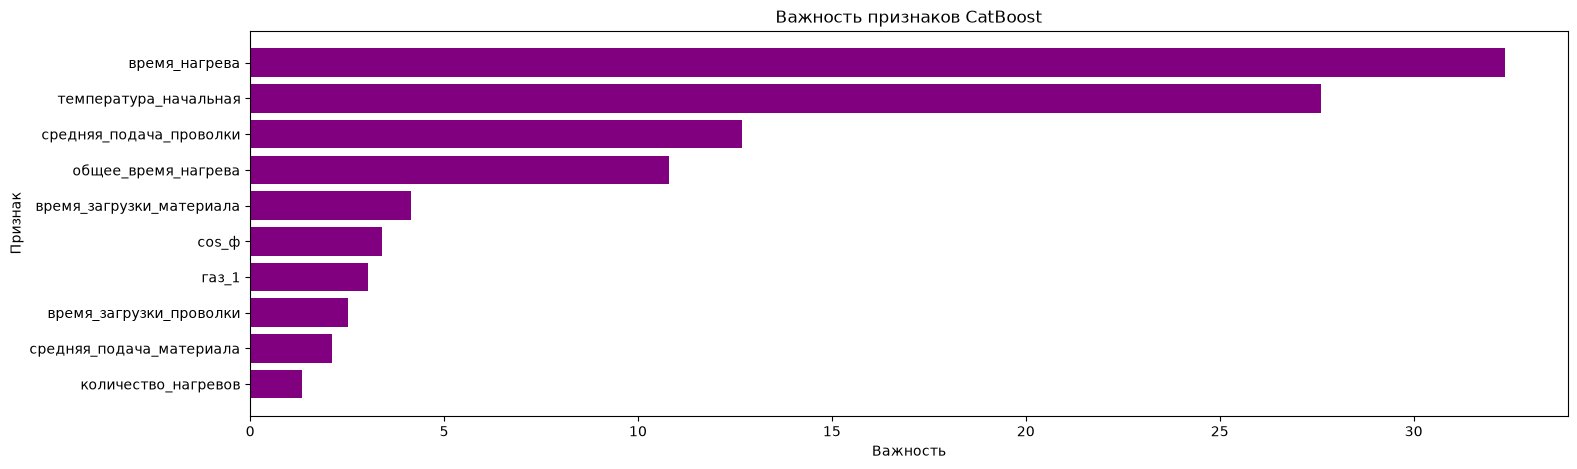

In [280]:
plt.figure(figsize=(17, 5))
plt.barh(importance_cb.index, importance_cb.values, color='Purple')
plt.xlabel("Важность")
plt.ylabel("Признак")
plt.title("Важность признаков CatBoost")
plt.gca().invert_yaxis()
plt.show()

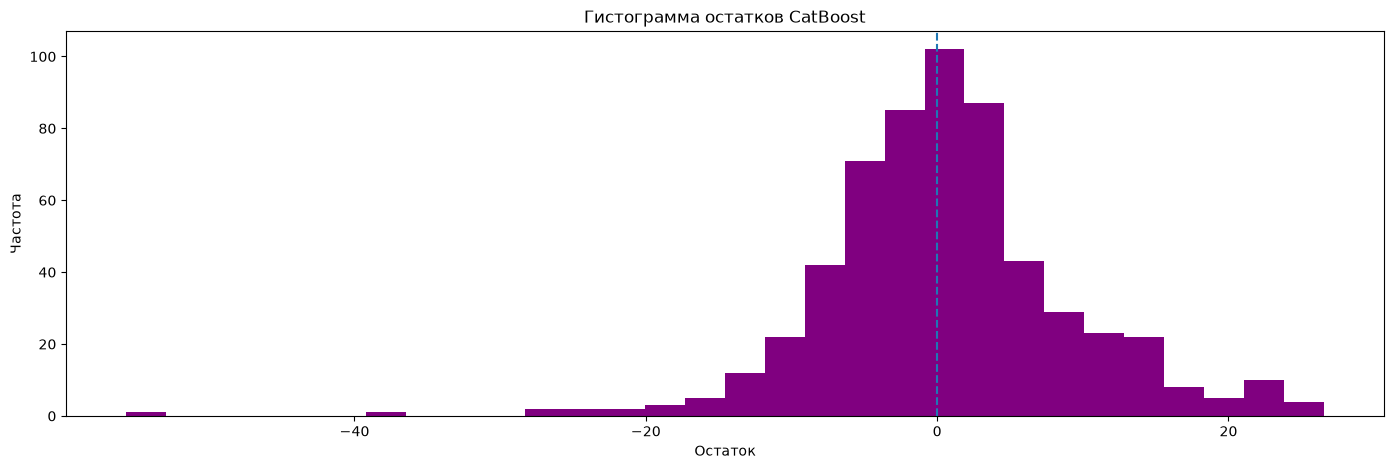

In [281]:
plt.figure(figsize=(17, 5))
plt.hist(residuals_cb, bins=30, color='Purple')
plt.xlabel("Остаток")
plt.ylabel("Частота")
plt.title("Гистограмма остатков CatBoost")
plt.axvline(0, linestyle="--")
plt.show()

- Распределение центрировано около 0;
- Примерно симметричное;
- Без сильного смещения вправо или влево;
- Без большого количества экстремальных выбросов;
- Большая часть ошибок должна находиться около нуля.

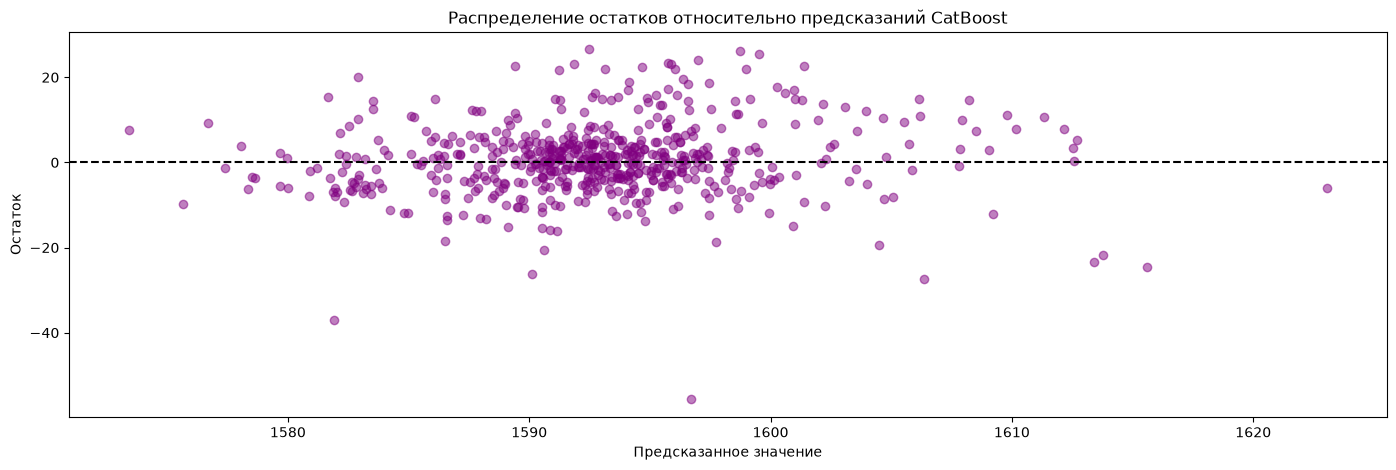

In [282]:
plt.figure(figsize=(17, 5))
plt.scatter(y_test_pred_cb, residuals_cb, alpha=0.5, color='Purple')
plt.axhline(0, linestyle="--", color='black')
plt.xlabel("Предсказанное значение")
plt.ylabel("Остаток")
plt.title("Распределение остатков относительно предсказаний CatBoost")
plt.show()

## Итоговый вывод

По результатам моделирования **CatBoost показал лучший результат среди рассмотренных моделей**. Среднее значение MAE по кросс-валидации составило **6.24°C**, а на независимой тестовой выборке — **6.19°C**. При этом тестовая ошибка даже немного ниже CV MAE, что говорит об отсутствии выраженного переобучения модели и о достаточно стабильном качестве прогнозирования на новых данных.

Значение **R² = 0.3948** показывает, что модель объясняет около **39.48% вариации конечной температуры**. При этом относительно невысокий R² при MAE около 6.2°C может быть связан с тем, что диапазон конечных температур в выборке достаточно узкий. Поэтому для практической оценки качества прогнозирования в данном случае MAE является более наглядной метрикой: в среднем ошибка модели составляет около **6.2°C**.

Анализ важности признаков показывает, что наибольший вклад в прогноз вносит **`время_нагрева` — 32.35%**, далее идут **`температура_начальная` — 27.61%** и **`средняя_подача_проволки` — 12.68%**. Значимыми также являются **`общее_время_нагрева` — 10.80%** и **`время_загрузки_материала` — 4.15%**. Остальные признаки имеют меньшую относительную важность: `cos_ф` — 3.39%, `газ_1` — 3.05%, `время_загрузки_проволки` — 2.52%, `средняя_подача_материала` — 2.11% и `количество_нагревов` — 1.34%.

Таким образом, **основными признаками, на которые опирается CatBoost при прогнозировании конечной температуры, являются параметры, характеризующие процесс нагрева, начальную температуру и подачу проволоки**. В частности, суммарная важность `время_нагрева`, `температура_начальная`, `средняя_подача_проволки` и `общее_время_нагрева` составляет около **83.4%**, что подчёркивает их значимость для модели. При этом важно учитывать, что `feature_importances_` отражает значимость признаков для модели, но не является доказательством причинно-следственной связи.

**Средний остаток составил 0.64°C**, что находится достаточно близко к нулю. Это означает, что выраженного систематического смещения прогнозов нет, хотя модель имеет небольшую тенденцию к занижению или завышению прогнозов в зависимости от принятого определения остатка. **Стандартное отклонение остатков составило 8.60°C**, а дисперсия — **74.02**, что характеризует разброс ошибок относительно среднего значения.

В целом CatBoost показал **MAE 6.19°C на тестовой выборке при R² 0.3948** и продемонстрировал стабильное качество относительно кросс-валидации (**6.24°C**). Поэтому из рассмотренных моделей **CatBoost можно выбрать в качестве основной модели для прогнозирования конечной температуры**. При этом значение R² показывает, что потенциал для дальнейшего улучшения модели остаётся: можно исследовать дополнительные технологические признаки, проверить нелинейные взаимосвязи и взаимодействия признаков, а также более подробно проанализировать случаи с наибольшими ошибками прогнозирования.


---